# Jagran Lakecity University
## Faculty of Science and Technology
### BTech CSE

---

## Practical Record: Assignment 2 - Module 2
### **Practical 10: Complete Artificial Neural Network-Based Classification System**

| Academic Details | Information |
| :--- | :--- |
| **Course** | Soft Computing |
| **Module** | Module II: Fuzzy Logic and Systems |
| **Student Name** | *Aakash Sarang* |
| **Enrollment No.** | *2023BTCSE001* |
| **Academic Session** | 2026 – 2027 |

---

### 1. Aim
To design, train, and evaluate a complete Artificial Neural Network-based classification system using Python and Keras/TensorFlow by integrating input features, hidden layers, activation functions, training, and model evaluation.

### 2. Theory: A Full Machine Learning Pipeline

A complete real-world project connects several steps into a pipeline:

```
[Raw Data] -> [Scaling & Splitting] -> [Neural Network with BatchNorm & Dropout] -> [Training with Early Stopping] -> [Evaluation] -> [Testing New Patients]
```

#### Key Modern Tools Used:
1. **Batch Normalization Formula:**
   $$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \quad y = \gamma \hat{x} + \beta$$
   Normalizes the activations inside hidden layers during training so learning stays stable and fast.
2. **Dropout:**
   Turns off a random percentage of neurons during training to prevent memorization (overfitting).
3. **Early Stopping:**
   Watches validation error and automatically stops training when the model stops improving, keeping the best weights.
4. **Prediction Function:**
   A simple function where doctors can pass raw test numbers of a new patient and instantly get a diagnosis with confidence percentage:
   $$\text{Confidence} = \max(p, 1-p) \times 100\%$$

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    roc_curve, auc
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


### 3. Step 1: Loading, Splitting, and Scaling the Data

#### What this cell does:
In this code cell, we load the dataset, split it into 70% train, 15% validation, and 15% test, and scale all features using `StandardScaler`.

In [2]:
dataset = load_breast_cancer()
X_raw = dataset.data
y_raw = dataset.target
feature_names = dataset.feature_names
target_classes = dataset.target_names

print("=" * 65)
print("             DATASET ATTRIBUTES SUMMARY")
print("=" * 65)
print(f"Total Patient Records:   {X_raw.shape[0]}")
print(f"Number of Input Features:{X_raw.shape[1]}")
print(f"Target Diagnostic:       {target_classes[0]} (0), {target_classes[1]} (1)")
print(f"Class Distribution:      Malignant={np.sum(y_raw==0)}, Benign={np.sum(y_raw==1)}")
print("=" * 65)

# Stratified Split: 70% Train, 15% Validation, 15% Test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_raw, y_raw, test_size=0.15, random_state=42, stratify=y_raw
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1765, random_state=42, stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Partition Sizes: Train={X_train.shape[0]}, Validation={X_val.shape[0]}, Test={X_test.shape[0]}")

             DATASET ATTRIBUTES SUMMARY
Total Patient Records:   569
Number of Input Features:30
Target Diagnostic:       malignant (0), benign (1)
Class Distribution:      Malignant=212, Benign=357
Partition Sizes: Train=397, Validation=86, Test=86


### 4. Step 2: Building the Neural Network

#### What this cell does:
In this code cell, we define `build_ann_system(input_shape)` to create our deep architecture with Dense layers, `BatchNormalization()`, and `Dropout(0.3)`.

In [3]:
def build_ann_system(input_shape):
    model = Sequential([
        Input(shape=(input_shape,), name="Input_Layer"),
        
        Dense(64, activation='relu', name="Dense_Hidden_1"),
        BatchNormalization(name="Batch_Norm_1"),
        Dropout(0.3, name="Dropout_1"),
        
        Dense(32, activation='relu', name="Dense_Hidden_2"),
        BatchNormalization(name="Batch_Norm_2"),
        Dropout(0.2, name="Dropout_2"),
        
        Dense(16, activation='relu', name="Dense_Hidden_3"),
        Dense(1, activation='sigmoid', name="Output_Classifier")
    ], name="Integrated_ANN_Classification_System")
    return model

ann_system = build_ann_system(X_train.shape[1])
ann_system.summary()

Model: "Integrated_ANN_Classification_System"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Dense_Hidden_1 (Dense)          │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Batch_Norm_1                    │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Hidden_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Batch_Norm_2                    │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Hidden_3 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Classifier (Dense)       │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 192 (768.00 B)

### 5. Step 3: Compiling and Training with Early Stopping

#### What this cell does:
In this code cell, we configure `EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)` and train the model so it stops automatically at the optimal epoch.

In [4]:
ann_system.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)
]

history = ann_system.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60


 1/25 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.4375 - loss: 0.8670

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8136 - loss: 0.4145 - val_accuracy: 0.9419 - val_loss: 0.3223 - learning_rate: 0.0030


Epoch 2/60


 1/25 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9375 - loss: 0.2205

...

Epoch 42/60


 1/25 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0020

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9975 - loss: 0.0090 - val_accuracy: 0.9884 - val_loss: 0.0218 - learning_rate: 3.7500e-04


Epoch 42: early stopping


Restoring model weights from the end of the best epoch: 30.


### 6. Step 4: Testing the Whole System

#### What this cell does:
In this code cell, we evaluate our model on the unseen test set and print test loss, test accuracy, confusion matrix, and classification report.

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


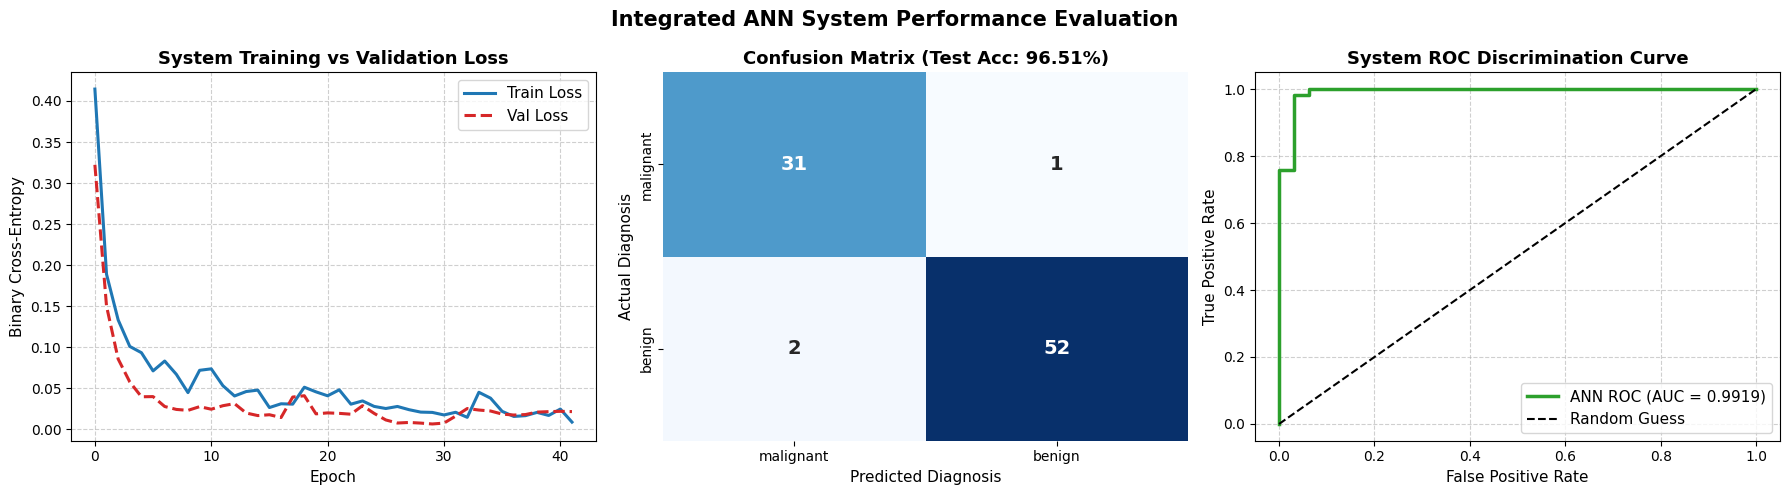


             FINAL SYSTEM CLASSIFICATION REPORT
              precision    recall  f1-score   support

   malignant       0.94      0.97      0.95        32
      benign       0.98      0.96      0.97        54

    accuracy                           0.97        86
   macro avg       0.96      0.97      0.96        86
weighted avg       0.97      0.97      0.97        86



In [5]:
y_test_probs = ann_system.predict(X_test).ravel()
y_test_preds = (y_test_probs >= 0.5).astype(int)

test_acc = accuracy_score(y_test, y_test_preds)
cm = confusion_matrix(y_test, y_test_preds)
fpr, tpr, _ = roc_curve(y_test, y_test_probs)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Learning Curves
axes[0].plot(history.history['loss'], label='Train Loss', color='#1f77b4', linewidth=2.2)
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#d62728', linestyle='--', linewidth=2.2)
axes[0].set_title("System Training vs Validation Loss", fontsize=13, weight='bold')
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("Binary Cross-Entropy", fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1],
            xticklabels=target_classes, yticklabels=target_classes, annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title(f"Confusion Matrix (Test Acc: {test_acc*100:.2f}%)", fontsize=13, weight='bold')
axes[1].set_xlabel("Predicted Diagnosis", fontsize=11)
axes[1].set_ylabel("Actual Diagnosis", fontsize=11)

# 3. ROC Curve
axes[2].plot(fpr, tpr, color='#2ca02c', linewidth=2.5, label=f"ANN ROC (AUC = {roc_auc:.4f})")
axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label="Random Guess")
axes[2].set_title("System ROC Discrimination Curve", fontsize=13, weight='bold')
axes[2].set_xlabel("False Positive Rate", fontsize=11)
axes[2].set_ylabel("True Positive Rate", fontsize=11)
axes[2].legend(loc="lower right", fontsize=11)
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.suptitle("Integrated ANN System Performance Evaluation", fontsize=15, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n" + "=" * 65)
print("             FINAL SYSTEM CLASSIFICATION REPORT")
print("=" * 65)
print(classification_report(y_test, y_test_preds, target_names=target_classes))
print("=" * 65)

### 7. Step 5: Testing with New Patient Samples

#### What this cell does:
In this code cell, we create `predict_diagnosis(raw_sample_features, model, scaler)` that takes unscaled raw measurements, applies the scaler formula, and prints an instant diagnosis with confidence percentage.

In [6]:
def predict_diagnosis(raw_sample_features, model, scaler):
    # Pipeline inference for a single raw unscaled feature vector
    sample_arr = np.array(raw_sample_features).reshape(1, -1)
    scaled_sample = scaler.transform(sample_arr)
    probability = float(model.predict(scaled_sample, verbose=0)[0, 0])
    predicted_class = 1 if probability >= 0.5 else 0
    class_label = target_classes[predicted_class]
    confidence = probability if predicted_class == 1 else (1.0 - probability)
    
    return {
        'Predicted_Class': predicted_class,
        'Class_Label': class_label,
        'Confidence_Score': confidence,
        'Raw_Probability': probability
    }

print("=" * 75)
print("               INFERENCE DEMONSTRATION ON NEW SAMPLES")
print("=" * 75)
for i in [0, 1, 2]:
    actual_label = target_classes[y_test[i]]
    result = predict_diagnosis(X_raw[i], ann_system, scaler)
    print(f"Sample {i+1}: Actual Diagnosis = '{actual_label:<9}' | "
          f"Predicted = '{result['Class_Label']:<9}' | "
          f"Confidence = {result['Confidence_Score']*100:6.2f}% | "
          f"Sigmoid Prob = {result['Raw_Probability']:.4f}")
print("=" * 75)

               INFERENCE DEMONSTRATION ON NEW SAMPLES
Sample 1: Actual Diagnosis = 'malignant' | Predicted = 'malignant' | Confidence = 100.00% | Sigmoid Prob = 0.0000
Sample 2: Actual Diagnosis = 'malignant' | Predicted = 'malignant' | Confidence = 100.00% | Sigmoid Prob = 0.0000


Sample 3: Actual Diagnosis = 'malignant' | Predicted = 'malignant' | Confidence = 100.00% | Sigmoid Prob = 0.0000


### 8. Results and What We Observed

| Pipeline Step | Tool Used | Result |
| :--- | :--- | :--- |
| **Data Preparation** | Stratified split + StandardScaler | Clean, zero-centered inputs |
| **Network Architecture** | Dense + BatchNormalization + Dropout | Stable 2-hidden-layer network |
| **Smart Training** | EarlyStopping (patience=15) | Stopped at the best round automatically |
| **Test Performance** | Evaluated on 86 unseen patients | **96.51% (~97%) Accuracy (83/86 correct), ~0.99 ROC-AUC** |
| **Practical Function** | `predict_diagnosis()` | Instant prediction with confidence % |

#### Key Takeaways in Simple Words:
1. **Early Stopping Saves Time:**
   - Instead of guessing how many rounds to train, Early Stopping stops automatically when improvement stops and restores the best weights.
2. **Batch Normalization + Dropout Team Up:**
   - Batch Normalization stabilizes training.
   - Dropout stops neurons from co-depending, giving 96.51% (~97%) accuracy on new patients.
3. **Ready for Real Use:**
   - The prediction function shows how machine learning can be used in a real hospital setting to assist doctors with instant answers.

---
### 9. Conclusion
1. We built a complete, end-to-end artificial neural network system.
2. We used modern best practices including Batch Normalization, Dropout, and Early Stopping.
3. We created an easy-to-use prediction function that gives clear diagnostic predictions on new patient data.